## Oppgave 2 a\)

In [100]:
import numpy as np
import matplotlib.pyplot as plt
import random
from numba import njit

In [101]:
#Initial grid
binding_sites = np.zeros(501)

center = len(binding_sites)//2
half_span = 50 #101 particles = 2*50 +1

binding_sites[center - half_span : center + half_span + 1] = 1

#Potential
@njit
def V1(x : int, k : float) -> float:
    """Constant potential

    Args:
        x: Position
        k: Intercept

    Returns:
        Potential value V1(x) = -k
    """
    return k

@njit
def V2(x : int, k : float) -> float:
    """Linear potential

    Args:
        x: Position
        k: Slope
        
    Returns:
        Potential value V2(x) = - k*x
    """
    return -k*x

#Probability
@njit
def p(x0 : int, V , beta : float, k : float) -> tuple[float, float]:
    """Probabliity of stepping to left or right from given position

    Args:
        x0: Current position
        V: Potential function V(x) that returns scalar potential value
        beta: Physical parameter 1/(k_B T)
        k: Potential physical parameter
        
    Returns:
        p_minus: Probablity of step to x0-1
        p_plus: Probablity of step to x0+1
    """
    
    p_minus = 1.0/(1.0 + np.exp(-beta*(V(x0 + 1, k) - V(x0 - 1, k))) + np.exp(-beta*(V(x0, k) - V(x0 - 1, k))))
    p_plus = 1.0/(1.0 + np.exp(-beta*(V(x0 - 1, k) - V(x0 + 1, k))) + np.exp(-beta*(V(x0, k) - V(x0 + 1, k))))
    
    return np.array([p_minus, p_plus])

In [102]:
#Walk simulation
@njit
def random_walk(initial_grid : np.ndarray, V, n_steps: int, beta : float, k : float) -> np.ndarray:
    """Simulates random walk without exclusion in given potential

    Args:
        initial_grid: Initial distribution of particles on binding sites
        V: Potential function V(x) that returns scalar potential value
        n_steps: Number of steps 
        beta: Physical parameter
        k: Potential physical paramater

    Returns: 
        grid: Updated grid with new particle positions 
    """
    grid = initial_grid.copy()
    n_sites = len(grid)
    
    for _ in range(n_steps):
        grid_new = np.zeros(n_sites)
        
        for i in range(n_sites):
            
            n_particles = int(grid[i])
            
            if n_particles == 0:
                continue
            
            for _ in range(n_particles):
                p_minus, p_plus = p(i, V, beta, k)
                r = np.random.uniform(0.0, 1.0)
                
                if r < p_minus:
                    grid_new[i - 1] += 1
                elif r > 1 - p_plus:
                    grid_new[i + 1] += 1
                else:
                    grid_new[i] += 1
                    
        grid = grid_new
        
    return grid

#Several simulations and step
def sim_walk(initial_grid: np.ndarray, V, n_steps: int, n_sim: int, beta: float, k: float) -> tuple[np.ndarray, np.ndarray]:
    """Run n_sim random-walk simulations, plot mean final particle distribution, and return the x-grid and averaged distribution

    Args:
        initial_grid: Initial distribution of particles
        V: Potential function V(x) that returns svalar potential value 
        n_steps:  Number of steps
        n_sim: Number of simulations
        beta: Physical parameter
        k: Potential physical paramater

    Returns:
        x: Site coordinates centered around zero
        mean_grid: Mean final particle distribution across all runs
    """
    n_sites = len(initial_grid)
    
    grids = np.zeros((n_sim, n_sites))
    
    for i in range(n_sim):
        grid = random_walk(initial_grid, V, n_steps, beta, k)
        grids[i] = grid

    mean_grid = np.mean(grids, axis = 0)
    x = np.arange(n_sites) - n_sites//2
        
    fig, ax = plt.subplots(figsize = (8, 4))
    
    ax.plot(x, mean_grid)
    ax.set_xlabel("x")
    ax.set_ylabel("Average particle count")
    ax.set_title(f"Average dist of particles after {n_steps} steps and {n_sim} runs")
    ax.grid()
    plt.show()
    
    return x, mean_grid

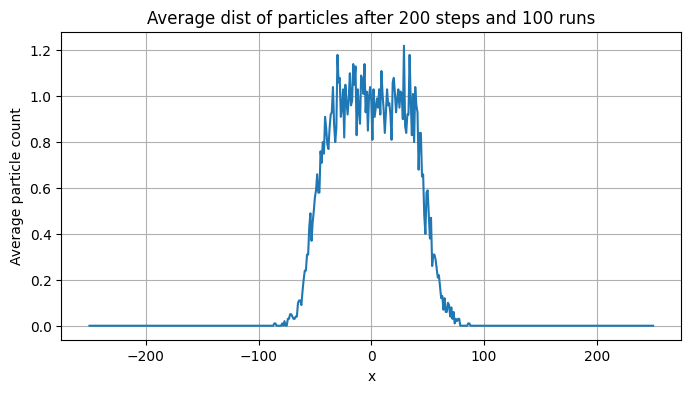

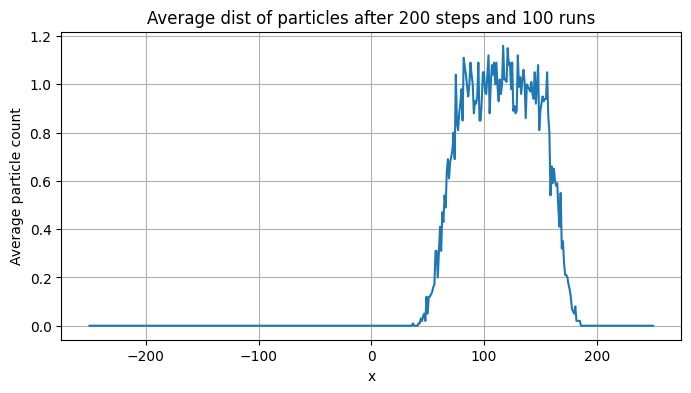

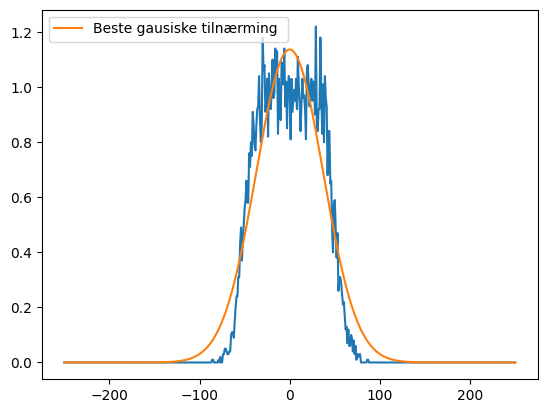

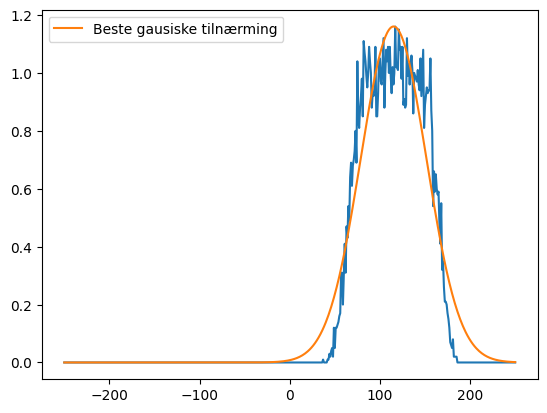

In [103]:
from scipy.optimize import curve_fit

kb = 1.38 * 10**-23
Temp = 298
beta2 = 1.0

x_1, mean_grid_1 = sim_walk(binding_sites, V1, n_steps = 200, n_sim = 100, beta = beta2, k = 1.0)
x_2, mean_grid_2 = sim_walk(binding_sites, V2, n_steps = 200, n_sim = 100, beta = beta2, k = 1.0)

###Plotter gausisk kurve
def gaussian(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

params, cov = curve_fit(gaussian, x_1, mean_grid_1)

A, mu, sigma = params
y_fit = gaussian(x_1, A, mu, sigma)


plt.plot(x_1, mean_grid_1, label="")
plt.plot(x_1, y_fit, label="Beste gausiske tilnærming ")
plt.legend()
plt.show()


def gaussian(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

A0 = mean_grid_2.max()
mu0 = x_2[np.argmax(mean_grid_2)]
sigma0 = np.std(x_2) 

params, cov = curve_fit(gaussian, x_2, mean_grid_2, p0=[A0, mu0, sigma0])

A, mu, sigma = params
y_fit = gaussian(x_2, A, mu, sigma)


plt.plot(x_2, mean_grid_2, label="")
plt.plot(x_2, y_fit, label="Beste gausiske tilnærming")
plt.legend()
plt.show()






Refleksjon 2a:

I oppgave 2a er partikklene uavhengige. I oppgaven lar vi hver partikkel ta 200 steg. fordelingen til enhver partikkel vil bli tilnærmet gausiskfordelt. Dette er fordi hver partikkel tar 200 uavhengige steg. Sentralgrenseteoremet konkluderer da med at sannsynlighetsfordelingen til hvor en bestemt partikkel havner blir tilnærmet gausiskfordelt. 

Ettersom vi tar gjennomsnitt av partikkeltetthetene til alle partikklene, tar vi dermed et gjennomsnitt av 101 partikkeltettheter som er tilnærmet gausiskfordelte rundt sin startposisjon. Vi vet at summen av flere normalfordelinger med samme sentrum blir gausiskfordelt. Men i oppgaven starter partikklene på forskjellige posisjoner. Dermed går det ikke helt mot en normalfordeling. Men siden gjennomsnitt av senterene er i 0, og partikklene sprer seg utover, vil fremdeles fordelingen ligne på en normalfordeling. Dette kan vi se der vi bruker scipy regression for beste tilnærmet gausisk kurve, og det er tydelig at det er noen avvik fra gaussisk. 

I oppgave 1c så vi at når eksponenten går mot 0, blir sannsynlighetene 1/3, så vi vil forvente en symmetrisk fordeling for plottet med konstant potensial. Dette stemmer med plottet. 

Men når potensialet blir linært synkende, blir sannynligheten for å gå mot høyre større enn sannsynlighet mot venstre, som fører til at fordelingen blir forskjøvet mot høyre. Dette stemmer også med konklusjonen våres i 1c.

## Oppgave 2 b)

In [104]:
@njit
def random_walk_exclusion(initial_grid: np.ndarray, V, n_steps: int, beta: float, k: float) -> np.ndarray:
    """Simulates random walk without exclusion in given potential

    Args:
        initial_grid: Initial distribution of particles
        V: Potential function V(x) that returns svalar potential value 
        n_steps:  Number of steps
        n_sim: Number of simulations
        beta: Physical parameter
        k: Potential physical paramater
        
    Returns:
        Grid with particles particle positions (0/1)
    """
  
    occupancy = initial_grid.astype(np.bool_) 
    positions = np.where(occupancy)[0].copy() 
    
    for _ in range(n_steps):
        np.random.shuffle(positions)
        
        for idx in range(len(positions)):
            i = positions[idx]
            
            p_minus, p_plus = p(i, V, beta, k)
            r = np.random.uniform(0.0, 1.0)
                
            if r < p_minus:
                new_i = i-1
            elif r > 1 - p_plus:
                new_i = i + 1
            else:
                new_i = i
        
            if occupancy[new_i]:
                continue
            
            occupancy[i] = False
            occupancy[new_i] = True
            positions[idx] = new_i
            
    return occupancy.astype(np.int64)

def sim_walk_exclusion(initial_grid: np.ndarray, V, n_steps: int, n_sim: int, beta: float, k: float) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Run n_sim simulations with and without exclusion, plot both mean final distributions, and return x plus both averages

    Args:
        initial_grid: Initial distribution of particles
        V: Potential function V(x) that returns svalar potential value 
        n_steps:  Number of steps
        n_sim: Number of simulations
        beta: Physical parameter
        k: Potential physical paramater

    Returns:
        x: Site coordinates centered around zero
        mean_grid: Mean final distribution for non_exclusion
        mean_grid_exclusion: Mean final dsitribution for exclusion
    """
    n_sites = len(initial_grid)
    
    grids = np.zeros((n_sim, n_sites))
    grids_exclusion = np.zeros((n_sim, n_sites))
    
    for i in range(n_sim):
        grid = random_walk(initial_grid, V, n_steps, beta, k)
        grid_exclusion = random_walk_exclusion(initial_grid, V, n_steps, beta, k)
        grids[i] = grid
        grids_exclusion[i] = grid_exclusion

    mean_grid = np.mean(grids, axis = 0)
    mean_grid_exclusion = np.mean(grids_exclusion, axis = 0)
    x = np.arange(n_sites) - n_sites//2
        
    fig, ax = plt.subplots(figsize = (8, 4))
    
    ax.plot(x, mean_grid, label = "Non-exclusion")
    ax.plot(x, mean_grid_exclusion, label = "Exclusion")
    ax.set_xlabel("x")
    ax.set_ylabel("Average particle count")
    ax.set_title(f"Average dist of particles after {n_steps} steps and {n_sim} runs")
    ax.grid()
    plt.legend()
    plt.show()
    
    return x, mean_grid, mean_grid_exclusion


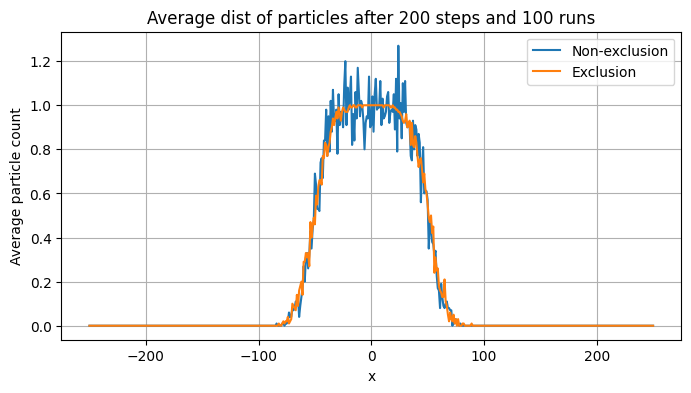

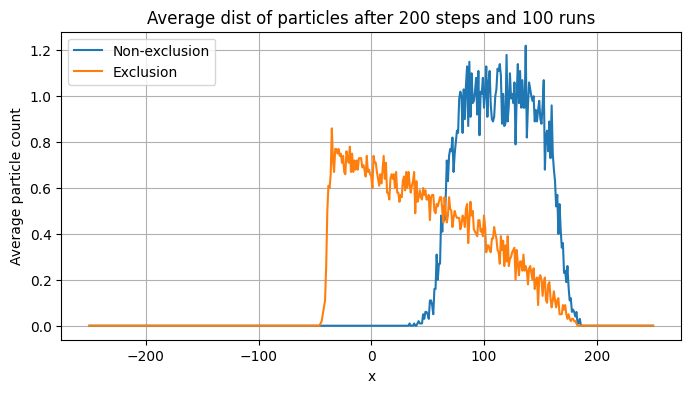

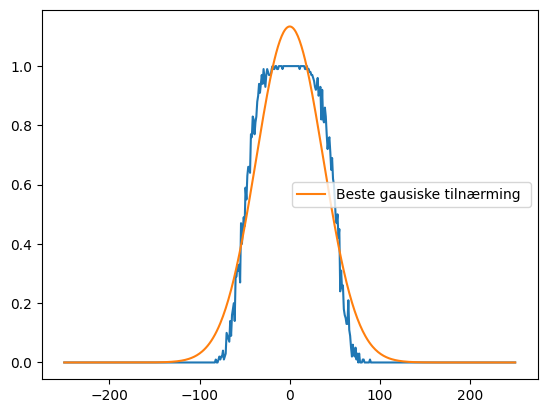

In [105]:
x_1, mean_grid, mean_grid_exclusion_1 = sim_walk_exclusion(binding_sites, V1, n_steps = 200, n_sim = 100, beta = beta2, k = 1.0)
x_2, mean_grid, mean_grid_exclusion_2 = sim_walk_exclusion(binding_sites, V2, n_steps = 200, n_sim = 100, beta = beta2, k = 1.0)

###Plotter gausisk kurve
params, cov = curve_fit(gaussian, x_1, mean_grid_exclusion_1)

A, mu, sigma = params
y_fit = gaussian(x_1, A, mu, sigma)


plt.plot(x_1, mean_grid_exclusion_1, label="")
plt.plot(x_1, y_fit, label="Beste gausiske tilnærming ")
plt.legend()
plt.show()

Refleksjon oppgave 2b

Nå er ikke partikklene uavhengige. Dette gjør at partikkler i midten ikke kan ha tetthet høyere enn 1. De sprer seg mer ut, noe vi ser på plottet for konstant potensial. Derfor blir det ikke nomalfoldelt, noe som vi også ser ut fra normalfordelingsplottet nederst. 

Men etterhvert partikklene sprer seg mer ut begynner overlapping å ha mindre å si, siden avstanden mellom partikklene øker, dermed ser vi på grafen for konstant potensial at fordeling med og uten kollisjon ser ganske like ut. 

Men når det blir tilført et potensial ser vi at dette påvirker ting mye mer. Partikklene kan ikke like lett gå mot høyre, siden dette fører til kollisjon. Så vi får mye mindre drift av partikkler. Partikklene til høyre må starte å dra mot hlyre, og så kan de partikklene litt mer til venstre begynne osv. Dermed får vi et plot som ser anderledes ut.

## Oppgave 2 c)

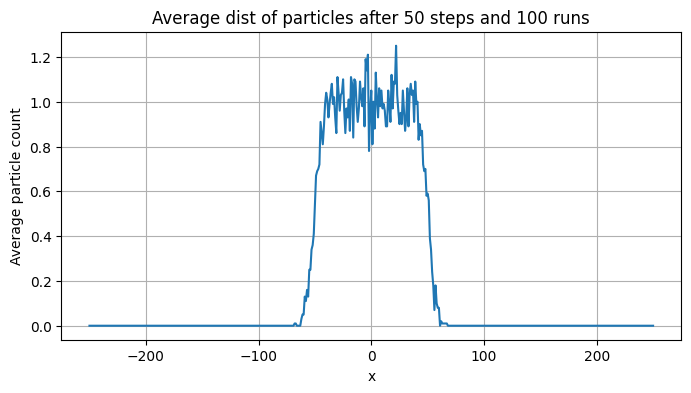

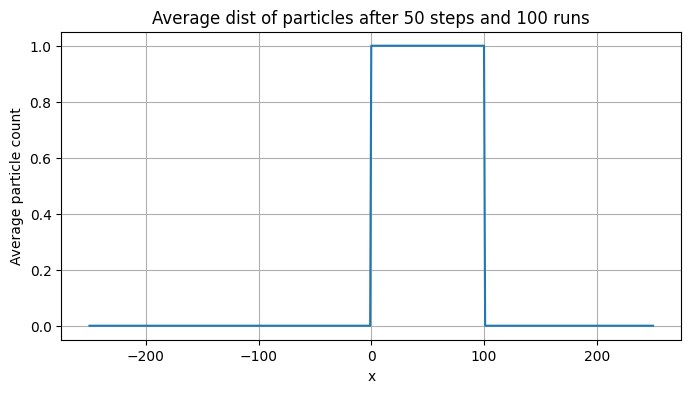

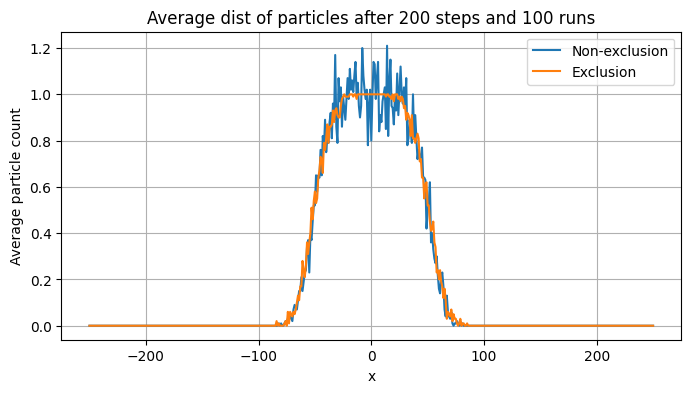

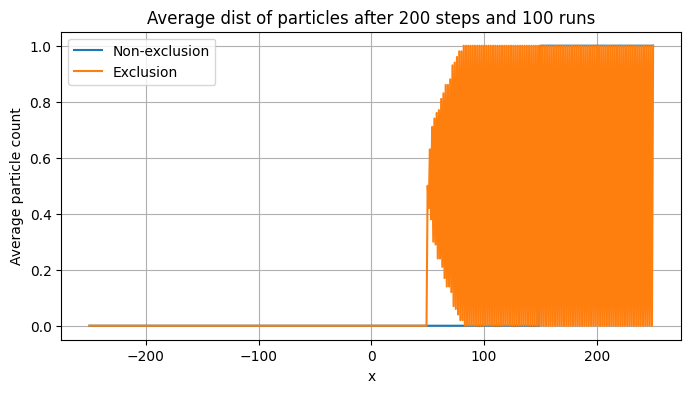

sannsynlighet for steg til høyre: 1.0


In [106]:
x, mean_grid = sim_walk(binding_sites, V1, n_steps = 50, n_sim = 100, beta = beta2, k = 1000.0)
x, mean_grid = sim_walk(binding_sites, V2, n_steps = 50, n_sim = 100, beta = beta2, k = 1000.0)

x, mean_grid, mean_grid_exclusion = sim_walk_exclusion(binding_sites, V1, n_steps = 200, n_sim = 100, beta = beta2, k = 1000.0)
x, mean_grid, mean_grid_exclusion = sim_walk_exclusion(binding_sites, V2, n_steps = 200, n_sim = 100, beta = beta2, k = 1000.0)


#Sannsynlighet for steg til høyre reknet ut
sum_sannsynlighet_høyre = 0
for pos in x:
    sum_sannsynlighet_høyre += p(pos, V2, 1.0, 1000 )
avg = sum_sannsynlighet_høyre/(len(x))

print("sannsynlighet for steg til høyre: " + str(avg[1]))

x, mean_grid = sim_walk(binding_sites, V1, n_steps = 50, n_sim = 100, beta = beta2, k = 1000.0)
x, mean_grid = sim_walk(binding_sites, V2, n_steps = 50, n_sim = 100, beta = beta2, k = 1000.0)

x, mean_grid, mean_grid_exclusion = sim_walk_exclusion(binding_sites, V1, n_steps = 200, n_sim = 100, beta = beta2, k = 1000.0)
x, mean_grid, mean_grid_exclusion = sim_walk_exclusion(binding_sites, V2, n_steps = 200, n_sim = 100, beta = beta2, k = 1000.0)


#Sannsynlighet for steg til høyre reknet ut
sum_sannsynlighet_høyre = 0
for pos in x:
    sum_sannsynlighet_høyre += p(pos, V2, 1.0, 1000 )
avg = sum_sannsynlighet_høyre/(len(x))

print("sannsynlighet for steg til høyre: " + str(avg[1]))

## Oppgave 3 a)

In [107]:
import numpy as np
from numba import njit
import math as math
import matplotlib.pyplot as plt

kb = 1.38 * 10**-23
Temp = 298
beta3 = 1

def plotter(titles: np.ndarray, x_labels: np.ndarray, y_labels: np.ndarray, x_arrays: np.ndarray, y_arrays: np.ndarray, rows: int, cols: int, size = (8,4), collective_title = "", labels = None):
    """Plot multiple x/y datasets across one or more subplots

    Args:
        titles: Array of titles, one per subplot
        x_labels: Array of x axis labels, one per subplot
        y_labels: Array of y axis labels, one per subplot
        x_arrays: Array of x axis value arrays, one per graph
        y_arrays: Array of y axis value arrays, one per graph
        rows: Number of subplot rows
        cols: Number of subplot columns
        size: Figure size as (width, height) tuple
        collective_title: Optional title displayed above all subplots
        labels: Array of legend labels, one per graph

    Returns:
        None
    """
    fig, ax = plt.subplots(rows, cols, figsize=size)
    axes_flattened = ax.flatten() if rows*cols > 1 else [ax]
    # Making repeating axes array for plotting multiple graphs in one plot
    # For example if we want 2 graphs per plot: [ax_0, ax_1] --> [ax_0, ax_0, ax_1, ax_1]
    if len(axes_flattened) < len(x_arrays):
        graphs_per_plot = len(x_arrays) // len(axes_flattened)
        new_axes_list = []
        for ax in axes_flattened:
            for _ in range(graphs_per_plot):
                new_axes_list.append(ax)
        axes_flattened = np.array(new_axes_list)
    else:
        graphs_per_plot = 1
    # Simple plotting for every x_arrays[i] and y_arrays[i] pair.
    for i, ax in enumerate(axes_flattened):
        ax.plot(x_arrays[i], y_arrays[i],label=labels[i] if labels is not None else None)

        # If this is the first graph being plotted on this axis, done now for indexing purpoes
        if i % graphs_per_plot == 0:
            ax.set_xlabel(x_labels[i//graphs_per_plot])
            ax.set_ylabel(y_labels[i//graphs_per_plot])
            ax.set_title(titles[i//graphs_per_plot])
        # If this is the last graph being plotted on this axis, done now so that legend gets all labels
        if i % graphs_per_plot == graphs_per_plot-1:
            ax.grid(True, alpha=0.3)
            ax.legend()
    if collective_title:
        fig.suptitle(collective_title)
    
    fig.tight_layout()
    plt.show()

@njit
def walk_dir(p_minus: float, p_plus: float) -> int:
    """Choose a random walk direction based on left/right move probabilities

    Args:
        p_minus: Probability of a move to the left (minus)
        p_plus: Probability of a move to the right (plus)

    Returns:
        step: Integer step value (-1, 0, or 1)
    """
    rand_val = np.random.ranf()
    if rand_val <= p_minus:
        return -1
    elif rand_val >= (1 - p_plus):
        return 1
    else:
        return 0


@njit
def v31(x: int, n_x: int, alpha: float, k: float, beta: float) -> float:
    """Calculate the periodic potential V31 at position x

    Args:
        x: Position on x axis
        n_x: Length of intervall for periodic potential V31
        alpha: Position of potential switch within n_x, pos = n_x*alpha
        k: Konstant for potential strength
        beta: Constant equal to 1/Kb*T

    Returns:
        v: Potential value at position x for V31
    """
    x_per = x % n_x
    if x_per < alpha * n_x:
        return k * x_per / (alpha * n_x * beta)
    else:
        x_per = x_per - n_x
        return -k * x_per / ((1 - alpha) * n_x * beta)


@njit
def v32(x: int, n_x: int, alpha: float, k: float, beta: float) -> float:
    """Calculate the periodic potential V32 at position x

    Args:
        x: Position on x axis
        n_x: Length of intervall for periodic potential V31
        alpha: Position of potential switch within n_x, pos = n_x*alpha
        k: Konstant for potential strength
        beta: Constant equal to 1/Kb*T

    Returns:
        v: Potential value at position x for V32
    """
    return 1 / beta


@njit
def probs_32(beta: float, x: int, n_x: int, alpha: float, k: float, t: int, t_p: int):
    """Calculate the probabilities of all possible moves with the partition function

    Args:
        beta: Constant equal to 1/Kb*T
        x: Position on x axis
        n_x: Length of intervall for periodic potential V31
        alpha: Position of potential switch within n_x, pos = n_x*alpha
        k: Konstant for potential strength
        t: Timestep witin [0,2*t_p]
        t_p: Time period between potential switches V31/V32

    Returns:
        p_minus, p_plus: Probabilites for a move to the left (minus) and right (plus)
    """
    # Checking for edge cases mentioned in 1c, this prevents unecessary calculations and underflow/overflow
    if (-0.01/beta)<(periodic_pot(t, t_p, x+1 , n_x, alpha, k, beta) - periodic_pot(t, t_p, x, n_x, alpha, k, beta))<(0.01/beta):
        return 1/3,1/3
    elif 100<(periodic_pot(t, t_p, x+1, n_x, alpha, k, beta) - periodic_pot(t, t_p, x, n_x, alpha, k, beta)):
        return 1,0
    elif -100>(periodic_pot(t, t_p, x+1, n_x, alpha, k, beta) - periodic_pot(t, t_p, x, n_x, alpha, k, beta)):
        return 0,1
    
    # Calculating exponents
    b = -beta * (periodic_pot(t, t_p, x,     n_x, alpha, k, beta) - periodic_pot(t, t_p, x + 1, n_x, alpha, k, beta))
    a = -beta * (periodic_pot(t, t_p, x - 1, n_x, alpha, k, beta) - periodic_pot(t, t_p, x + 1, n_x, alpha, k, beta))
    c = -beta * (periodic_pot(t, t_p, x + 1, n_x, alpha, k, beta) - periodic_pot(t, t_p, x - 1, n_x, alpha, k, beta))
    d = -beta * (periodic_pot(t, t_p, x,     n_x, alpha, k, beta) - periodic_pot(t, t_p, x - 1, n_x, alpha, k, beta))

    p_plus = 1.0 / (1.0 + np.exp(a) + np.exp(b))
    p_minus = 1.0 / (1.0 + np.exp(c) + np.exp(d))

    return p_minus, p_plus

@njit
def probs_3(beta: float, x: int, n_x: int, alpha: float, k: float, t: int, t_p: int):
    """Calculate the probabilities of all possible moves with the partition function

    Args:
        beta: Constant equal to 1/Kb*T
        x: Position on x axis
        n_x: Length of intervall for periodic potential V31
        alpha: Position of potential switch within n_x, pos = n_x*alpha
        k: Konstant for potential strength
        t: Timestep witin [0,2*t_p]
        t_p: Time period between potential switches V31/V32

    Returns:
        p_minus, p_plus: Probabilites for a move to the left (minus) and right (plus)
    """

    if -0.01/beta<(periodic_pot(t, t_p, x, n_x, alpha, k, beta) - periodic_pot(t, t_p, x + 1, n_x, alpha, k, beta))<0.01/beta:
        return 1/3,1/3
    b = -beta * (periodic_pot(t, t_p, x, n_x, alpha, k, beta) - periodic_pot(t, t_p, x + 1, n_x, alpha, k, beta))
    a = -beta * (periodic_pot(t, t_p, x - 1, n_x, alpha, k, beta) - periodic_pot(t, t_p, x + 1, n_x, alpha, k, beta))
    c = -beta * (periodic_pot(t, t_p, x + 1, n_x, alpha, k, beta) - periodic_pot(t, t_p, x - 1, n_x, alpha, k, beta))
    d = -beta * (periodic_pot(t, t_p, x, n_x, alpha, k, beta) - periodic_pot(t, t_p, x - 1, n_x, alpha, k, beta))

    if a > 50:
        a = 50
    elif a < -50:
        a = -50
    if b > 50:
        b = 50
    elif b < -50:
        b = -50
    if c > 50:
        c = 50
    elif c < -50:
        c = -50
    if d > 50:
        d = 50
    elif d < -50:
        d = -50

    p_plus = 1.0 / (1.0 + np.exp(a) + np.exp(b))
    p_minus = 1.0 / (1.0 + np.exp(c) + np.exp(d))

    return p_minus, p_plus

@njit
def periodic_pot(t: int, t_p: int, x: int, n_x: int, alpha: float, k: float, beta: float) -> float:
    """Select the periodic potential based on the current time step

    Args:
        t: Timestep witin [0,2*t_p]
        t_p: Time period between potential switches V31/V32
        x: Position on x axis
        n_x: Length of intervall for periodic potential V31
        alpha: Position of potential switch within n_x, pos = n_x*alpha
        k: Konstant for potential strength
        beta: Constant equal to 1/Kb*T

    Returns:
        v: Potential value at position x for the active potential (V31 or V32)
    """
    if t % (2 * t_p) < t_p:
        return v32(x, n_x, alpha, k, beta)
    else:
        return v31(x, n_x, alpha, k, beta)


@njit
def walk_step(n_x: int, alpha: float, k: float, n_p: int, t: int, t_p: int, x: np.ndarray, interval: int, beta: float):
    """Perform one timestep of the random walk for all particles

    Args:
        n_x: Length of intervall for periodic potential V31
        alpha: Position of potential switch within n_x, pos = n_x*alpha
        k: Konstant for potential strength
        n_p: Number of particles
        t: Timestep witin [0,2*t_p]
        t_p: Time period between potential switches V31/V32
        x: Array of particle positions
        interval: Length of position interval (wrap-around boundary)
        beta: Constant equal to 1/Kb*T

    Returns:
        x: Updated array of particle positions after one timestep
        flow: Normalized net flow (n_plus - n_minus) / n_p for this timestep
    """

    n_plus = 0
    n_minus = 0
    # Finding and performing steps for all the particles
    for j in range(len(x)):
        p_minus, p_plus = probs_3(beta, x[j], n_x, alpha, k, t, t_p)
        step = walk_dir(p_minus, p_plus)

        if step == 1:
            n_plus += 1
            if x[j] == (interval-1):
                x[j] = 0
            else:
                x[j] += step
        elif step == -1:
            n_minus += 1
            if x[j] == 0:
                x[j] = interval-1
            else:
                x[j] += step

    flow = (n_plus - n_minus) / n_p
    return x, flow


def sim_3(t_p: int, n_x: int, alpha: float, k: float, n_p: int, cycles: int, interval: int, beta: float):
    """Simulate the random walk with a switching periodic potential over multiple cycles

    Args:
        t_p: Time period between potential switches V31/V32
        n_x: Length of intervall for periodic potential V31
        alpha: Position of potential switch within n_x, pos = n_x*alpha
        k: Konstant for potential strength
        n_p: Number of particles
        cycles: Number of full cycles to simulate
        interval: Length of position interval (wrap-around boundary)
        beta: Constant equal to 1/Kb*T

    Returns:
        x: Final array of particle positions after all cycles
        avg_flow: Array of average flow per cycle
    """
    # Creating array with n_p elements (positions) in range [0,interval),
    # where there are n_p//interval repetitions of each position
    x = np.array([[i for _ in range((n_p // interval))] for i in range(interval)]).flatten()
    avg_flow = np.zeros(cycles)

    # Going through all periods t_p for all cycles and adding their J_avg to the avg_flow array
    for cycle in range(cycles):
        flow_t = np.zeros(2 * t_p)
        for t in range(2 * t_p):
            x, flow = walk_step(n_x, alpha, k, n_p, t, t_p, x, interval, beta)
            flow_t[t] = flow
        avg_flow[cycle] = np.mean(flow_t)

    return x, avg_flow


x_10, avg_flow_08 = sim_3(500, 100, 0.8, 1000, 1200, 10, 200, beta3)
x_10, avg_flow_01 = sim_3(500, 100, 0.1, 1000, 1200, 10, 200, beta3)

In [108]:
print(avg_flow_08)
print(avg_flow_01)


[-0.03058333 -0.01375    -0.0125     -0.01225    -0.01391667 -0.01158333
 -0.01008333 -0.0115     -0.0135     -0.0125    ]
[0.03883333 0.0285825  0.02966667 0.02625083 0.0295     0.02983333
 0.02791667 0.02866667 0.02675    0.02675   ]


### i)
Vi får ikke-null partikkelstrømmer fordi potensial 1 har en positiv derivert for 80% av det periodiske intervallet, mot de 20%ene som er dekt av den negative deriverte. Dette vil si at hvis partiklene er uniformt fordelte vil 80% av de ha størst sjanse til å gå mot venstre, fordi dette er "nedover potensialgrafen" for de, mens resten vil ha størst sjanse for å gå mot høyre. I praksis vil denne sjansen for å gå mot høyre eller venstre være 100% da potensialstyrken er veldig stor i dette eksempelet, noe som fører til at vi får netto forflytning mot venstre, også kjent som negativ gjennomsnittlig partikkelflyt ($J_{avg}$). Enda en ting som gjør at denne strømningen blir betydelig forskjellig fra null, og ikke skalerer linært med alpha er at når alpha blir veldig liten eller veldig stor er det ikke bare flere partikler som beveger seg samme vei, men de nært toppunktet ($\alpha$) beveger seg også lengre, slik at flyten blir proposjonal med $c * \alpha^2$.

Fysiskt kan dette forklares ved å tenke på partiklene som kuler som ligger oppå potensialgrafen, Disse kulene vil da rulle mot deres lokale minimum for potensial energi, og vil da med andre ord forflytte seg mot venstre for 80% av hver periode, og mot venstre for de andre 20%ene. hvis vi da legger sammen den distansen alle kulene har bevegd seg, mens vi tar hensyn til fortegn på bevegelsen, vil vi se at denne blir negativ. Vi har valgt å plotte potensial 1 med $\alpha = 0.8$ under for å illustrere potensialgrafen.





/var/folders/_v/dlt4x0r10s9f0fp_6w_psw7m0000gn/T/ipykernel_50358/4202925612.py:53: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


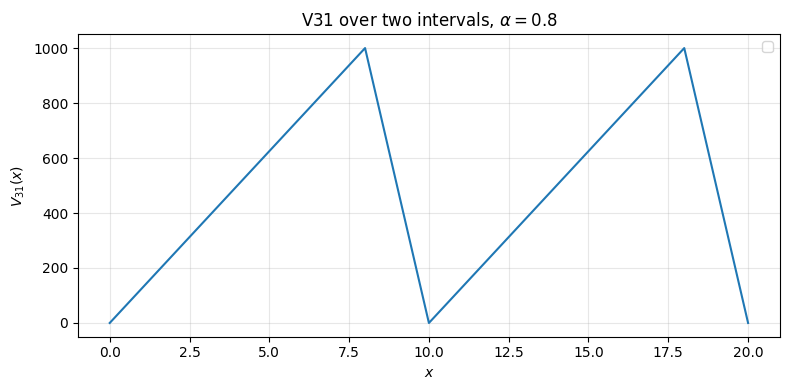

In [109]:
x_vals = np.arange(0, 20.0001)
v_vals = np.array([v31(x, 10, 0.8, 1000,beta3) for x in x_vals])

plotter(
    np.array([r"V31 over two intervals, $\alpha = 0.8$"]),
    np.array([r"$x$"]),
    np.array([r"$V_{31}(x)$"]),
    np.array([x_vals]),
    np.array([v_vals]),
    1, 1
)

### ii)
Vi ser at den første målingen av $J_{avg}$ er betydelig større enn alle de andre målingene som er relatvit like. Dette an forklares ved at partiklene orginalt er jevt fordelt for å så bevege seg slik at de i praksis alle er ved minimalt potensial under potensial 1, deretter byttes potensialet til potensial 2 som er konstant, og fører til tilfeldig bevegelse, på grunn av at denne tilfeldige bevegelsen skjer i en begrenset tidsperiode, og at partiklene i utgangspunktet alle er veldig nær posisjon 0, forventer vi at de er betydelig nærmere posisjon 0 enn når de var jevnt fordelte ved tidspunktet der vi bytter tilbake til potensial 1. Dette gjør at vi får mindre bevegelse og derfor en lavere $J_{avg}$.


### iii)
Her ser vi at $J_{avg}$ er mot høyre isteden for venstre (positiv isteden for negativ) som vi forventer da potensial 1 nå har mye større del med negativ derivert enn positiv derivert. 


Oppgave 3 b)

/var/folders/_v/dlt4x0r10s9f0fp_6w_psw7m0000gn/T/ipykernel_50358/4202925612.py:53: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


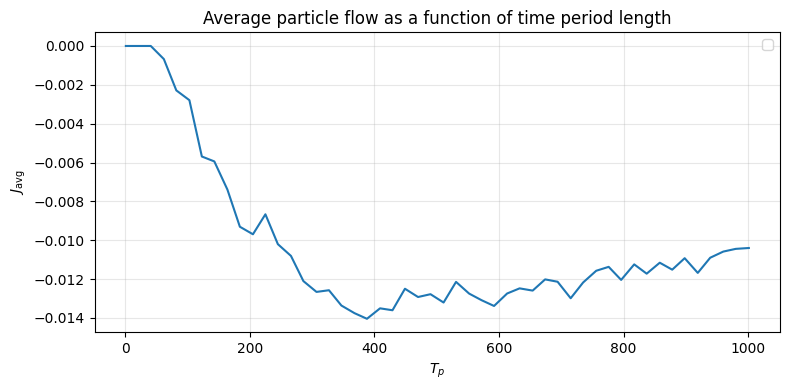

In [110]:
@njit
def sim_3b(t_p: int, n_x: int, alpha: float, k: float,
           n_p: int, pos1: int, pos2: int, interval: int, beta: float):
    """Simulate the random walk with a switching periodic potential for two particle groups

    Args:
        t_p: Time period between potential switches V31/V32
        n_x: Length of intervall for periodic potential V31
        alpha: Position of potential switch within n_x, pos = n_x*alpha
        k: Konstant for potential strength
        n_p: Number of particles
        pos1: Initial position of the first group of particles
        pos2: Initial position of the second group of particles
        interval: Length of position interval (wrap-around boundary)
        beta: Constant equal to 1/Kb*T

    Returns:
        x: Final array of particle positions after one cycle
        avg_flow: Average flow over one full cycle
    """
    # Making an array of particles equally divided between position 1 and 2
    x = np.array([[pos1 for _ in range(n_p // 2)],
                  [pos2 for _ in range(n_p // 2)]]).flatten()

    flow_t = np.zeros(2 * t_p)

    for t in range(2 * t_p):
        x, flow = walk_step(n_x, alpha, k, n_p, t, t_p, x, interval, beta)
        flow_t[t] = flow
    avg_flow = np.mean(flow_t)

    return x, avg_flow

# Initializing t_p array with 50 evenly spaced t_p values and empty flow array with same length of type np.float64
t_p_array = np.int64(np.linspace(1, 1001, 50))
flow_array_3b = np.zeros(len(t_p_array), dtype=np.float64)

# Simulating the J_avg for all values of t_p and adding them to flow array for plotting
for i in range(len(t_p_array)):
    x, avg_flow_3b = sim_3b(t_p_array[i], 100, 0.8, 1000, 40 * 100, 0, 100, 200, beta3)
    flow_array_3b[i] = avg_flow_3b

plotter(np.array(["Average particle flow as a function of time period length"]), np.array([r"$T_p$"]), np.array([r"$J_{\mathrm{avg}}$"]), np.array([t_p_array]), np.array([flow_array_3b]), 1, 1)


Vi observer at magnituden $J_{avg}$ starter rundt null, for å så gå opp til et maksimum ved $T_p \in [350, 550]$, magnituden av flyten minker etter dette. En tolkning av den initielle økningen i magnitude er at partiklene trenger noe tid for å spre seg utover mens potensial 2 er aktivt for at vi skal se noe utslag i $J_{avg}$. Dette kan forklares ved at partiklene vil gå veldig lite vekk fra minimum i potensial 1 ved et lavt antall tidssteg som fører til at veien tilbake til minimum er like lang uavhengig av hvilken vei de gikk da asymmetrien i potensialet i prakisis "ikke oppdages" av partiklene, dette gjør da at $J_{avg}$ blir null.

For å forklare hvorfor magnituden igjen går ned ved en tilstrekkelig høy verdi for $T_p$, kan vi se på formelen for å regne ut $J_{avg}$. Vi har tenkt oss at denne er i noen grad porposjonal med hvor langt partiklene er unna minimumet i potensial 1, dette vil i vårt tilfelle makismeres når partiklene er uniformt fordelt, når vi ser bort fra ekstremt usannsynlige tilfeller. Videre vet vi at $J_{avg}$ er lineært omvendtproposjonalt med T_p, mens den gjennomsnittlige avstanden fra en partikkel til minimum i potensial 1 er ikke-linært proposjonal $T_p$, Vi ser en stor effekt av økning i $T_P$ i starten, som minker etterhvert som $T_P$ øker. Dette gjør at vi vil får en kamp mellom det positive bidraget til magnituden av flyten fra $T_p$ som har en negativ derivert, og det negative bidraget fra $T_p$ som har en konstant derivert, gitt at det positive bidraget starter større enn det negative må vi da finne et eller annet punkt $T_{p_{maks}} > T_{p_0}$ der magnituden av $J_{avg}$ maksimeres.

## Oppgave 3 c)

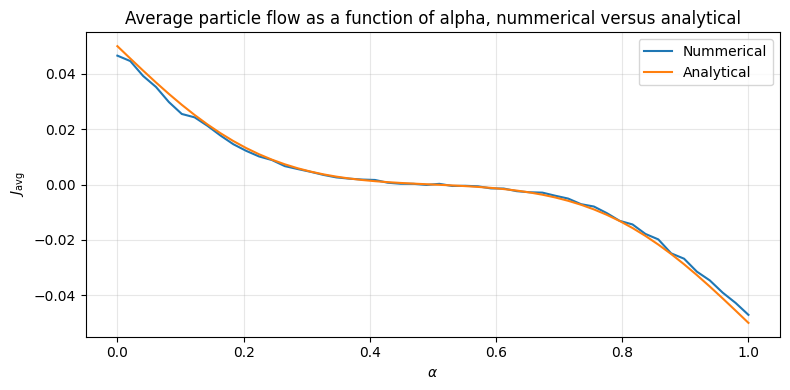

In [111]:
import math as math

def analytic_flow(n_x: int, t_p: int, alpha: float):
    """Calculate the analytical average particle flow as a function of alpha, n_x and t_p

    Args:
        n_x: Length of intervall for periodic potential V31
        t_p: Time period between potential switches V31/V32
        alpha: Position of potential switch within n_x, pos = n_x*alpha

    Returns:
        flow: Analytical average particle flow for the given parameters
    """
    return n_x/(4*t_p) * (
        math.erfc(alpha*n_x/2*np.sqrt(3/t_p))
        - math.erfc((1-alpha)*n_x/2*np.sqrt(3/t_p))
    )




# Initializing alpha array with 50 evenly spaced t_p values and empty flow arrays with same length of type np.float64
alpha_array = np.linspace(0, 1, 50)
flow_array_3c = np.zeros(len(alpha_array), dtype=np.float64)
analytic_flow_array_3c = np.zeros(len(alpha_array), dtype=np.float64)

# Simulating the J_avg for all values of alpha and adding them to flow arrays for plotting
for i in range(len(alpha_array)):
    x, avg_flow = sim_3b(500, 100, alpha_array[i], 1000, 40*100, 0, 100, 200, beta3)
    flow_array_3c[i] = avg_flow
    analytic_flow_array_3c[i] = analytic_flow(100, 500, alpha_array[i])

plotter(np.array(["Average particle flow as a function of alpha, nummerical versus analytical"]),
         np.array([r"$\alpha$"]), np.array([r"$J_{\mathrm{avg}}$"]),
         np.array([alpha_array for _ in range(2)]), np.array([flow_array_3c,analytic_flow_array_3c]), 1, 1,
         labels=np.array(["Nummerical","Analytical"]))





Den nummeriske løsningen vår er veldig lik den analytiske løsningen som tyder på at oppgaven er løst rett. Vi ser en korrelasjon mellom $|\alpha-0.5|$ og magnituden av $J_{avg}$, vi kan se at magnituden av den andre deriverte av funksjonen når maks rundt $\alpha = 0.75$ og $\alpha = 0.25$.

## Oppgave 3 d)

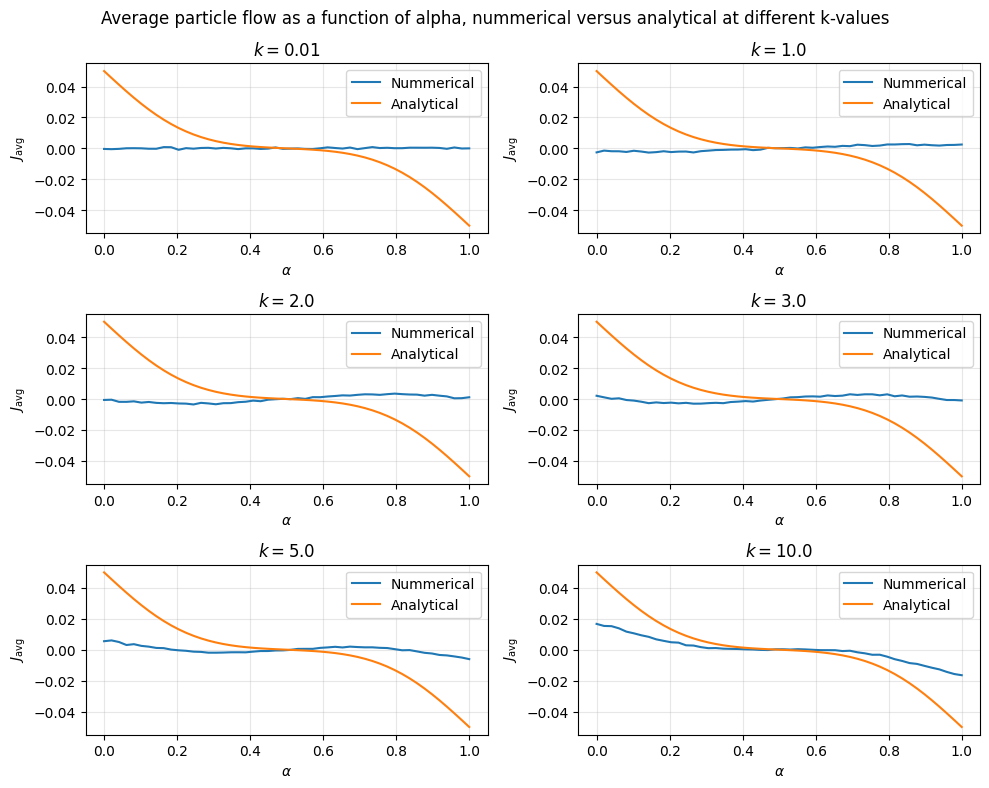

In [112]:
k_array = np.array([0.01, 1, 2, 3, 5, 10])
flow_array_list = []

for k in k_array:
    # Initializing alpha array with 50 evenly spaced alpha values and empty flow arrays with same length of type np.float64
    alpha_array = np.linspace(0, 1, 50)
    flow_array_3d = np.zeros(len(alpha_array), dtype=np.float64)
    analytic_flow_array_3d = np.zeros(len(alpha_array), dtype=np.float64)

    # Simulating the J_avg for all values of alpha and adding them to a list of flow arrays for plotting
    for i in range(len(alpha_array)):
        x, avg_flow = sim_3b(500, 100, alpha_array[i], k, 40*100, 0, 100, 200, beta3)
        flow_array_3d[i] = avg_flow
        analytic_flow_array_3d[i] = analytic_flow(100, 500, alpha_array[i])
    flow_array_list.append(flow_array_3d)
    flow_array_list.append(analytic_flow_array_3d)
flow_arrays = np.array(flow_array_list)

title_array = np.array([rf"$k = {k}$" for k in k_array])

plotter(title_array, np.array([r"$\alpha$" for _ in range(len(k_array))]),
         np.array([r"$J_{\mathrm{avg}}$" for _ in range(len(k_array))]),
         np.array([alpha_array for _ in range(len(k_array)*2)]), flow_arrays, 3, 2,size=(10,8),
         collective_title="Average particle flow as a function of alpha, nummerical versus analytical at different k-values",
         labels=np.array([["Nummerical","Analytical"] for _ in range(len(k_array))]).flatten())


## Oppgave 3 e)

In [113]:
# Initializing t_p array with 20 evenly spaced t_p values and empty flow array with same length of type np.float64
t_p_array = np.int64(np.linspace(80, 1500, 50))
flow_array_3e = np.zeros(len(t_p_array), dtype=np.float64)
analytic_flow_array_3e = np.zeros(len(t_p_array), dtype=np.float64)

# Simulating the J_avg for all values of t_p and adding them to flow array for plotting
for i in range(len(t_p_array)):
    x, avg_flow_3e = sim_3b(t_p_array[i], 10, 0.8, 1000, 40 * 10, 0, 10, 20,beta3)
    flow_array_3e[i] = avg_flow_3e
    analytic_flow_array_3e[i] = analytic_flow(10, t_p_array[i], 0.8)

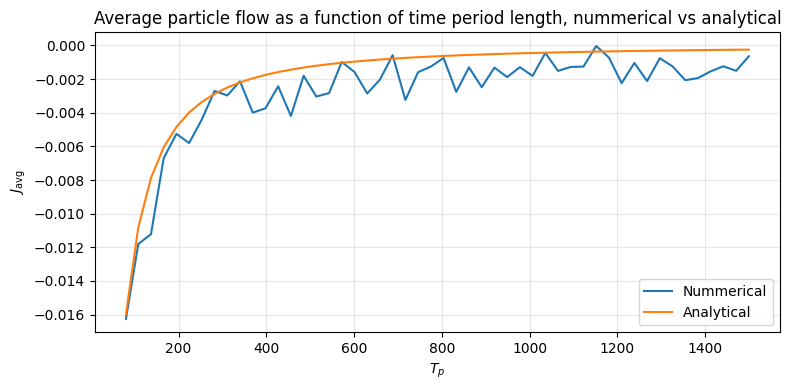

In [114]:
plotter(np.array(["Average particle flow as a function of time period length, nummerical vs analytical"]), np.array([r"$T_p$"]), np.array([r"$J_{\mathrm{avg}}$"]), np.array([t_p_array for _ in range(2)]), np.array([flow_array_3e,analytic_flow_array_3e]), 1, 1,labels=np.array(["Nummerical","Analytical"]))
plt.show()


Grafene er lingende, forskjeller er diskutert i del f.

## Oppgave 3 f)

Resultatene fra 3d viser at den analytiske løsningen er svært unøyaktig for svakere potensialer. Dette kan forklares ved å se på anntakelsene den analytiske løsningnen bruker, løsningen antar at partiklene beveger seg mot det lokale potensial minimumet, noe som kun skjer i praksis når potensialet og tidsperioden er tilstrekkelig store. En betydelig begrensning av den analytiske løsningen er derfor behovet for sterke potensialer.

resultatene fra 3e viser at den analytiske løsningen antar at magnituden til $J_{avg}$ går mot null noe fortere enn den nummeriske løsningen viser. Dette foresakes trolig av en rekke forenklinger, 1. anntakelse om at alle partiklene når lokalt minimum i løpet av perioden der "sag-potensialet" er aktivt, 2. anntakelsen om like startbetingelser på for hver syklus, 3. anntakelsen om at partikler alltid går den veien de har størst sannynlighet for å gå. Det er også mulig bruk av kontinuerlige poisjoner i den analytiske løsningen mot diskrete posisjoner i den nummeriske løsningen har en innvirkning, spesielt med tanke på at $N_x$ er veldig liten i 3e, og at potensial forksjellen mellom to posisjoner derfor blir veldig stor.



## Oppgave 4a\)

In [115]:
@njit
def build_initial(width: int, partition: int, Nx: int, Ns: int, Np: int = -1) -> np.ndarray:
    """Build an initial grid with particles spread out around the center
    
    Args:
        width: Total width of particles
        partition: How much of grid should be particle-covered
        Nx: Sites per sawtooth period
        Ns: Number of sawtooth periods
        Np: Number of particles to place. Default Np = -1 computes from partition. 
        
    Returns:
        initial_grid : 1D array (0/1) of length Ns*Nx where 1 symbolizes occupied site
    """
    binding_sites = np.zeros(Ns*Nx)
    center = len(binding_sites)//2
    initial_grid = binding_sites.copy()
    
    N_possible = len(binding_sites)//width
    if Np == -1:
        Np = N_possible//partition
    if Np <= 0:
        return initial_grid
    elif Np > N_possible:
        Np = N_possible
        
    initial_grid[center] = 1
    half = (Np - 1)//2
    
    for n in range(1, half + 1):
        initial_grid[(center - n*width)%len(binding_sites)] = 1
        initial_grid[(center + n*width)%len(binding_sites)] = 1
    
    if Np%2 == 0:
        initial_grid[(center + (half + 1) * width) % len(binding_sites)] = 1
    
    return initial_grid

   
    
#Random walk
@njit
def random_walk_exclusion_sawtooth(initial_grid: np.ndarray, 
                                   Tp: int, 
                                   width: int, 
                                   Nx: int, Ns: int, Nc: int,
                                   alpha: float, k: float, beta: float,
                                   h: int, store_positions:bool = True) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Simulates random walk with exclusion principle in rachet potential

    Args:
        initial_grid: Initial distribution of particles (0/1)
        Tp : Half-period of potential-switching
        width: Total width of particles
        Nx: Sites per sawtooth period
        Ns: Number of sawtooth periods
        Nc: Number of full cycles
        alpha: Potential physical parameter
        k: Potential physical parameter
        beta: Physical parameter
        h: Time-step size
        store_positions: Defaults to True. If True, store particle positions for each time step

    Returns:
        occupancy: Array(True/False) describing particle locations in final grid
        cycle_avg_J: Cycle-averaged current 
        positions_arr: Stores positions (T, Np) for each time step if enabled, else (1,1) zero-array
    """
    T = 2*Nc*Tp
    occupancy = initial_grid.astype(np.bool_)
    positions = np.where(occupancy)[0].copy()
    Np = len(positions)
    if store_positions:
        positions_arr = np.zeros((T, Np), dtype=np.int64)
    else:
        positions_arr = np.zeros((1, 1), dtype=np.int64)
        
    J_arr = np.zeros(T)
    order = np.arange(Np)
    
    for t in range(0, T, h):
        nplus = 0
        nminus = 0
        np.random.shuffle(order)
        
        for n in range(Np):
            idx = order[n]
            i = positions[idx]
            
            p_minus, p_plus = probs_3(beta, i, Nx, alpha, k , t, Tp)
            
            step = walk_dir(p_minus, p_plus)
            new_i = (i + step)%(Ns*Nx)

            check_left = np.arange(new_i - width + 1, new_i +1)%len(occupancy)
            check_right = np.arange(new_i , new_i + width)%len(occupancy)
            
            if new_i == (i + 1) % (Ns*Nx) and occupancy[check_right].any():
                continue
            elif new_i == (i - 1) % (Ns*Nx) and occupancy[check_left].any():
                continue
            
            occupancy[i] = False
            occupancy[new_i] = True
            positions[idx] = new_i
            
            if new_i == (i + 1) % (Ns*Nx): 
                nplus += 1
            elif new_i == (i - 1) % (Ns*Nx): 
                nminus += 1
            
        J_arr[t] = (nplus - nminus)/Np
        if store_positions:
            positions_arr[t] = positions
            
    n_cycles = len(J_arr)//(2*Tp)       
    J_reshaped = J_arr.reshape(n_cycles, 2*Tp)
    cycle_avg_J = np.zeros(n_cycles)
    
    for c in range(n_cycles):
        cycle_avg_J[c] = J_reshaped[c].mean()
        
    return occupancy.astype(np.int64), cycle_avg_J, positions_arr

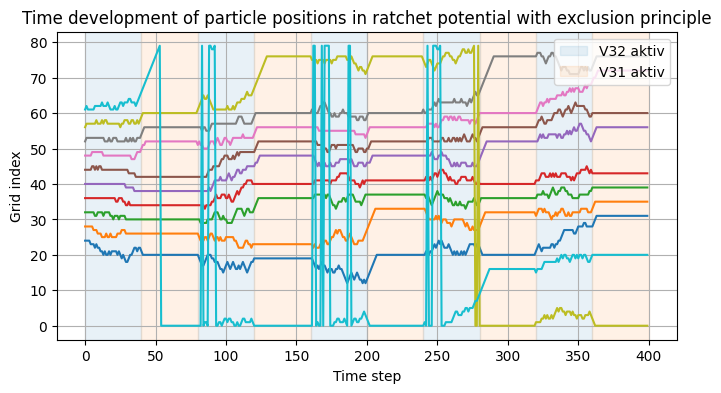

In [131]:
def plot_walk_exclusion_sawtooth(Tp: int, 
                                 width: int, 
                                 Nx: int, Ns: int, Nc: int, 
                                 alpha: float, beta: float, k: float,
                                 Np: int = -1, 
                                 h: int = 1) -> None:
    """Plots the time evolution of particle positions in random walk in ratchet potential with exclusion principle

    Args:
        Tp : Half-period of potential-switching
        width: Total width of particles
        Nx: Sites per sawtooth period
        Ns: Number of sawtooth periods
        Nc: Number of full cycles
        alpha: Potential physical parameter
        k: Potential physical parameter
        beta: Physical parameter
        Np: Number of particles. Defaults to -1.
        h: Time-step size. Defaults to 1. 

    Returns:
        None
    """
    initial_grid = build_initial(width, 2, Nx, Ns, Np)
    grid, cycle_av_J, positions_arr = random_walk_exclusion_sawtooth(initial_grid, Tp, width, Nx, Ns, Nc, alpha, k, beta, h)
    
    fig, ax = plt.subplots(figsize = (8, 4))
    
    time = np.arange(len(positions_arr))

    for p in range(positions_arr.shape[1]):
        ax.plot(time, positions_arr[:, p])
        
    #Periodic potential plot
    T = len(positions_arr)
    for t0 in range(0, T, 2*Tp):
        t1 = t0 + Tp
        t2 = t0 + 2*Tp
        
        ax.axvspan(t0, t1, color="tab:blue", alpha=0.10,
               label="V32 aktiv" if t0 == 0 else None, zorder=0)
        ax.axvspan(t1, t2, color="tab:orange", alpha=0.10,
               label="V31 aktiv" if t0 == 0 else None, zorder=0)
        

    
    ax.set_title("Time development of particle positions in ratchet potential with exclusion principle")
    ax.set_xlabel("Time step")
    ax.set_ylabel("Grid index")  
    ax.grid()  
    ax.legend(loc = "upper right")

    plt.show()

    return None

plot_walk_exclusion_sawtooth(Tp=40, width=4, Nx=20, Ns=4, Nc=5, alpha=0.2, beta = beta4, k=1000)

Vi ser at partiklene aldri krysser hverandre, og alltid har en avstand større en b imellom hverandre, som stemmer med antagelsene våres. Det er lite variasjon i de miderste partiklene, siden disse vil ha en større tendens til å kollidere med andre partikler, som vi ser er reflektert i at det ofte er lange områder uten bevegelse (flat graf). Det ser ut til at det er en drift mot høyre (pluss) som vi diskuterte i oppgave 3, så dette stemmer også godt. 

## Oppgave 4b\) 

In [117]:
def plot_current_particle_exclusion_sawtooth(Tp: int, 
                                             width: int, 
                                             Ns: int, Nx: int, Nc: int, N_min: int, N_max: int, 
                                             alpha: float, k: float, beta: float, 
                                             h: float = 1) -> None:
    """Plot cycle-averaged current J_avg as function of particle density rho for the exclusion sawtooth model

    Args:
        Tp : Half-period of potential-switching
        width: Total width of particles
        Ns: Number of sawtooth periods
        Nx: Sites per sawtooth period
        Nc: Number of full cycles
        N_min: Minimum amount of particles. Should be at least 1 to avoid division-by-zero error
        N_max: Maximum amount of particles
        alpha: Potential physical parameter
        k: Potential physical parameter
        beta: Physical parameter
        h: Time-step size. Defaults to 1.

    Returns:
        None: Displays the plot
    """
    Np_arr = np.arange(N_min, N_max + 1)
    cycle_avg_J_arr = np.zeros(len(Np_arr))
    rho_arr = np.zeros(len(Np_arr))
    
    for i, Np in enumerate(Np_arr):
        rho = width * Np /(Ns * Nx)
        initial_grid = build_initial(width, 2, Nx, Ns, Np)
        
        grid, cycle_avg_J, positions_arr = random_walk_exclusion_sawtooth(initial_grid, Tp, width, Nx, Ns, Nc, alpha, k, beta, h, store_positions = False)
        
        cycle_avg_J_arr[i] = cycle_avg_J.mean()
        rho_arr[i] = rho
        
    fig, ax = plt.subplots(figsize = (8, 4))
    ax.plot(rho_arr, cycle_avg_J_arr)
    ax.set_title("Average current as function of particle density")
    ax.set_xlabel(r"$\rho$")
    ax.set_ylabel(r"$J_{avg}$")
    ax.grid()

    plt.show()
    
    return None

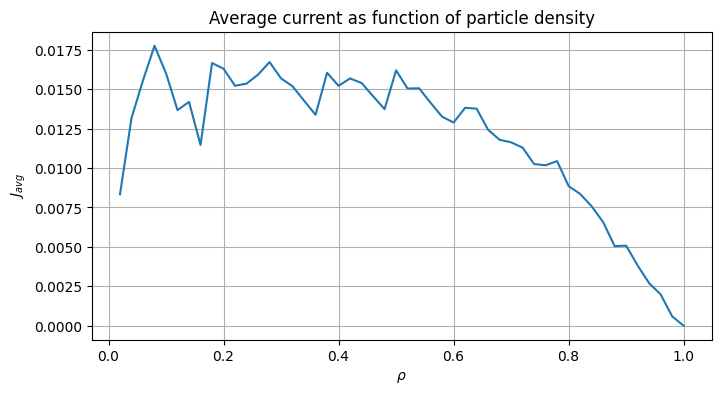

In [118]:
plot_current_particle_exclusion_sawtooth(Tp = 300, width = 20, Ns = 10, Nx = 100, Nc = 100, N_min = 1, N_max = 50, alpha = 0.2, k = 1000, beta = 1)

Når partikkeltettheten øker forventer vi flere kollisjoner og mindre drift av partikler, derfor burde $J_{avg}$ minke for høyere $\rho$, som også er reflektert i grafen.

## Oppgave 4c\)

In [119]:
def plot_current_period_exclusion_sawtooth(width: int, 
                                            Tp_min : int,
                                            Tp_max: int,
                                            Ns: int, Nx: int, 
                                            alpha: float, k: float, beta: float, 
                                            h: float = 1) -> None:
    """Plot cycle-averaged current J_avg as function of half period T_p for the exclusion sawtooth model

    Args:
        width: Total width of particles
        Tp_min: Minimum half period
        Tp_max: Maximum half period
        Ns: Number of sawtooth periods
        Nx: Sites per sawtooth period
        alpha: Potential physical parameter
        k: Potential physical parameter
        beta: Physical parameter
        h: Time-step size. Defaults to 1.

    Returns:
        None: Displays the plot
    """
    Tp_arr = np.arange(Tp_min, Tp_max + 1, 10)
    cycle_avg_J_arr = np.zeros(len(Tp_arr))
    
    for i, Tp in enumerate(Tp_arr):
        Nc = 30000//Tp
        initial_grid = build_initial(width, 2, Nx, Ns)
        
        grid, cycle_avg_J, positions_arr = random_walk_exclusion_sawtooth(initial_grid, Tp, width, Nx, Ns, Nc, alpha, k, beta, h, store_positions = False)
        
        cycle_avg_J_arr[i] = cycle_avg_J.mean()
    
    fig, ax = plt.subplots(figsize = (8, 4))
    ax.plot(Tp_arr, cycle_avg_J_arr)
    ax.set_title(r"Average current as function of half-period with $T_p N_c = 30 000$")
    ax.set_xlabel(r"$T_p$")
    ax.set_ylabel(r"$J_{avg}$")
    ax.grid()
    
    return None

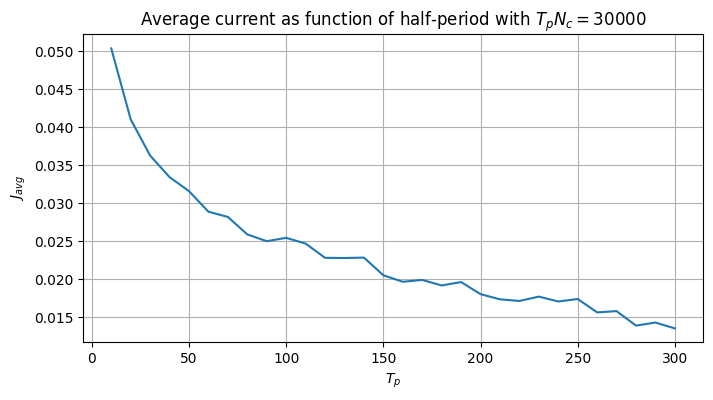

In [120]:
plot_current_period_exclusion_sawtooth(width = 20, Tp_min = 10, Tp_max = 300, Ns = 10, Nx = 100, alpha = 0.2, k = 1000, beta = 1)

Høyere $T_p$ gir lengre faser av hvert potensial. For høyere $T_p$ varer da fasene lengre, og systemet rekker i større grad å nærme seg likevekt i hver fase, som gir mindre netto drift per syklus. Dette reflekteres også i plottet. Siden $T_p N_c$ holdes konstant vil også større $T_p$ bety færre sykluser, som øker usikkerheten. Uten å kunne fastlå dette med sikkerhet, ser det ut som at volatiliteten også øker med $T_p$, som er å forvente. 

### Oppgave 4d)

Valgt vitenskapelig artikkel: https://arxiv.org/pdf/1410.4981


#### Beskrivelse av modellen

Artikkelen undersøker likevekts-egenskapene til et system av interagerende partikler med hard core exclusion og hvordan de beveger seg i et diskret éndimensjonalt vekslende ratchet-potensial. Dette er tilsvarende det vi har undersøkt, men i tillegg ser artikkelen på effekten av et uordnet potensial, som blir gjort ved å bryte periodisiteten til sawtooth-potensialet.

Systemet har to forskjellige tilstander, "ON" og "OFF". I OFF-tilstanden ($V=0$) diffunderer partiklene til naboposisjoner, hver tilstanden har i utgangspunktet lik sannsynlighet, men dette vil endres ved kollisjon. I ON-tilstanden hopper partiklene med overgangssannsynlighet (for tilstandsendring $n \rightarrow m$, der $m \in \{ n-1, n, n+1 \}$):

$$P(n\rightarrow m) = r\cdot \min(1,\exp\left(\beta(V(n)-V(m))\right)), \hspace{5mm} r=1/\beta.$$

De bruker en såkalt Metropolis-algoritme (https://en.wikipedia.org/wiki/Metropolis%E2%80%93Hastings_algorithm) hvor steg i retning av et lavere potensiale vil akspteres med sannsynlighet $r$, mens et steg i retning av et større potensiale vil skaleres med Boltzmann-faktoren. Dette vil i praksis gi kvalitativt lignende resultater, særlig blir likevektsfordelingen lik, men det er også noen forskjeller, hvilket skal diskuteres videre.

I kapittel 2 i artikkelen undersøkes det hard-core ekslusjon i et ratchet-potensial, men uten å gi partiklene en bredde. Imidlertid vil partikkeltettheten $\rho = N/(wL)$ aldri overstige 1, mens i oppgave 4 setter partikkelbredden $b$ en øvre grense $\rho_{\max} = 1$ gjennom $\rho = bN_p/(N_s N_x)$.

Modellen deres viser at man får en global strøm av partiklene som er tetthetsavhengig, i likhet med det vi fant. Dessuten skal vi i likhet med artikkelens modell anta at partikkelbredden er 1.

Vi kan kan gjenskape Figur 2b i artikkelen som viser den gjennomsnittlige hastigheten til systemet av partikler i ratchet-potensialet. Den gjennomsnittlige hastigheten er proporsjonal til den gjennomsnittelige nettostrømmen av partikler, $J_{avg}$. Diffusjonskoeffesienten kan empirisk beregnes som

$$D = \frac{\text{MSD}}{2T_p} = \frac{\left< (x-x_0)^2\right>}{2T_p} = \text{Var}\left[J_{avg}\right]T_p = \frac{1}{2} \text{Var}\left[J_{avg}\right]T_{cycle} \hspace{1mm};\hspace{5mm} T_{cycle} = 2T_p,$$

der MSD er "Mean squared displacement" (kilde: https://en.wikipedia.org/wiki/Fick%27s_laws_of_diffusion).

In [121]:
# Implement the Metropolis-algorithm like in the article
# This is mainly redefining of already implemented functions 

@njit
def probs_metropolis(beta: float, x: int, n_x: int, alpha: float, k: float, t: int, t_p: int):
    """Calculate move probabilities using Metropolis rates P(n->m) = r*min(1, exp(-beta*(V(m)-V(n))))
    where r = 1/beta.
    Args:
        beta: Constant equal to 1/kb*T
        x: Position on x axis
        n_x: Length of interval for periodic potential
        alpha: Position of potential switch within n_x, pos = n_x*alpha
        k: Constant for potential strength
        t: Timestep within [0, 2*t_p]
        t_p: Time period between potential switches
    Returns:
        p_minus, p_plus: Probabilities for a move to the left (minus) and right (plus)
    """
    r = 1.0 / beta  

    V0  = periodic_pot(t, t_p, x, n_x, alpha, k, beta)
    Vm  = periodic_pot(t, t_p, x - 1, n_x, alpha, k, beta)
    Vp  = periodic_pot(t, t_p, x + 1, n_x, alpha, k, beta)

    dV_plus  = beta * (Vp - V0)  
    dV_minus = beta * (Vm - V0)  

    # Metropolis-rates, min(1, exp(-dV))
    if dV_plus <= 0:
        p_plus = r
    else:
        p_plus = r * np.exp(-dV_plus)

    if dV_minus <= 0:
        p_minus = r
    else:
        p_minus = r * np.exp(-dV_minus)

    return p_minus, p_plus


#Random walk with Metropolis-rates
@njit
def random_walk_exclusion_sawtooth_m(initial_grid: np.ndarray, 
                                   Tp: int, 
                                   width: int, 
                                   Nx: int, Ns: int, Nc: int,
                                   alpha: float, k: float, beta: float,
                                   h: int, store_positions:bool = True) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Simulates random walk with exclusion in rachet potential with Metropolis-rates

    Args:
        initial_grid: Initial distribution of particles (0/1)
        Tp : Half-period of potential-switching
        width: Total width of particles
        Nx: Sites per sawtooth period
        Ns: Number of sawtooth periods
        Nc: Number of full cycles
        alpha: Potential physical parameter
        k: Potential physical parameter
        beta: Physical parameter
        h: Time-step size
        store_positions: Defaults to True. If True, store particle positions for each time step

    Returns:
        occupancy: Array(True/False) describing particle locations in final grid
        cycle_avg_J: Cycle-averaged current 
        positions_arr: Stores positions (T, Np) for each time step if enabled, else (1,1) zero-array
    """
    T = 2*Nc*Tp
    occupancy = initial_grid.astype(np.bool_)
    positions = np.where(occupancy)[0].copy()
    Np = len(positions)
    if store_positions:
        positions_arr = np.zeros((T, Np), dtype=np.int64)
    else:
        positions_arr = np.zeros((1, 1), dtype=np.int64)
        
    J_arr = np.zeros(T)
    order = np.arange(Np)
    
    for t in range(0, T, h):
        nplus = 0
        nminus = 0
        np.random.shuffle(order)
        
        for n in range(Np):
            idx = order[n]
            i = positions[idx]
            
            p_minus, p_plus = probs_metropolis(beta, i, Nx, alpha, k , t, Tp)
            
            step = walk_dir(p_minus, p_plus)
            new_i = (i + step)%(Ns*Nx)

            check_left = np.arange(new_i - width + 1, new_i +1)%len(occupancy)
            check_right = np.arange(new_i , new_i + width)%len(occupancy)
            
            if new_i == (i + 1) % (Ns*Nx) and occupancy[check_right].any():
                continue
            elif new_i == (i - 1) % (Ns*Nx) and occupancy[check_left].any():
                continue
            
            occupancy[i] = False
            occupancy[new_i] = True
            positions[idx] = new_i
            
            if new_i == (i + 1) % (Ns*Nx): 
                nplus += 1
            elif new_i == (i - 1) % (Ns*Nx): 
                nminus += 1
            
        J_arr[t] = (nplus - nminus)/Np
        if store_positions:
            positions_arr[t] = positions
            
    n_cycles = len(J_arr)//(2*Tp)       
    J_reshaped = J_arr.reshape(n_cycles, 2*Tp)
    cycle_avg_J = np.zeros(n_cycles)
    
    for c in range(n_cycles):
        cycle_avg_J[c] = J_reshaped[c].mean()
        
    return occupancy.astype(np.int64), cycle_avg_J, positions_arr

In [122]:
# Estimate the mean velocity and diffusion

@njit
def compute_velocity_diffusion_omega(omega_arr, random_walk_fun, Np, width, Nx, Ns, alpha, k, beta, Nc=20):
    """Computes mean particle velocity and diffusion coefficient for each frequency omega.
    Args:
        omega_arr: Array of frequencies omega = 1/(2*Tp)
        random_walk_fun: Random walk function
        Np: Number of particles
        width: Particle width
        Nx: Sites per sawtooth period
        Ns: Number of sawtooth periods
        alpha: Asymmetry parameter of sawtooth potential
        k: Potential strength
        beta: Inverse temperature
        Nc: Number of full cycles per simulation. Defaults to 20
    Returns:
        v_arr: Array of mean particle velocities for each omega value
        D_arr: Array of diffusion coefficients for each omega value
    """
    v_arr = np.zeros(len(omega_arr))
    D_arr = np.zeros(len(omega_arr))

    for i, omega in enumerate(omega_arr):
        Tp = int(1 / (2 * omega))
        if Tp < 1:
            continue

        initial_grid = build_initial(width, 2, Nx, Ns, Np)
        _, cycle_avg_J, _ = random_walk_fun(
            initial_grid, Tp, width=width, Nx=Nx, Ns=Ns, Nc=Nc,
            alpha=alpha, k=k, beta=beta, h=1, store_positions=False
        )


        T_cycle = 2 * Tp
        v_arr[i] = cycle_avg_J.mean()
        D_arr[i] = (np.var(cycle_avg_J) * T_cycle) / 2

    return v_arr, D_arr


def plot_velocity_diffusion_omega(omega_arr, v_arr, D_arr, metropolis):
    """Plots mean particle velocity and diffusion coefficient as functions of flashing frequency omega.
    Args:
        omega_arr: Array of flashing frequencies omega = 1/(2*Tp)
        v_arr: Array of mean particle velocities
        D_arr: Array of diffusion coefficients
        metropolis: Uses metropolis rates or not
    Returns:
        None: Displays the plot
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    v_title = "Mean particle velocity as function of frequency"
    w_title = "Diffusion coefficient as function of frequency"


    if metropolis:
        v_title += " (Metropolis rates)"
        w_title += " (Metropolis rates)"

    ax1.plot(omega_arr, v_arr, 'o-')
    ax1.set_xlabel(r"$\omega$")
    ax1.set_ylabel(r"$v$")
    ax1.set_title(v_title)
    ax1.set_xscale("log")
    ax1.grid()

    ax2.plot(omega_arr, D_arr, 'o-')
    ax2.set_xlabel(r"$\omega$")
    ax2.set_ylabel(r"$D$")
    ax2.set_title(w_title)
    ax2.set_xscale("log")
    ax2.grid()

    plt.tight_layout()
    plt.show()

#### Overgangssannsynlighet med Boltzmannsstatistikk

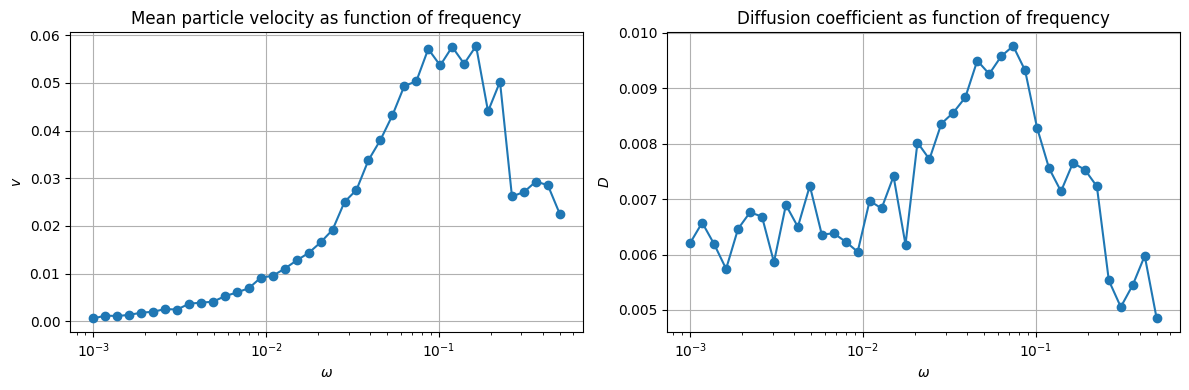

In [123]:
omega_arr = np.logspace(-3, np.log10(0.5), 40)

v_arr, D_arr = compute_velocity_diffusion_omega(
    omega_arr, random_walk_exclusion_sawtooth, Np=25, width=1, Nx=6, Ns=50,
    alpha=1/6, k=5.0, beta=2.0, Nc=500
)

plot_velocity_diffusion_omega(omega_arr, v_arr, D_arr, metropolis=False)

#### Overgangssannsynlighet med Metropolis-rater

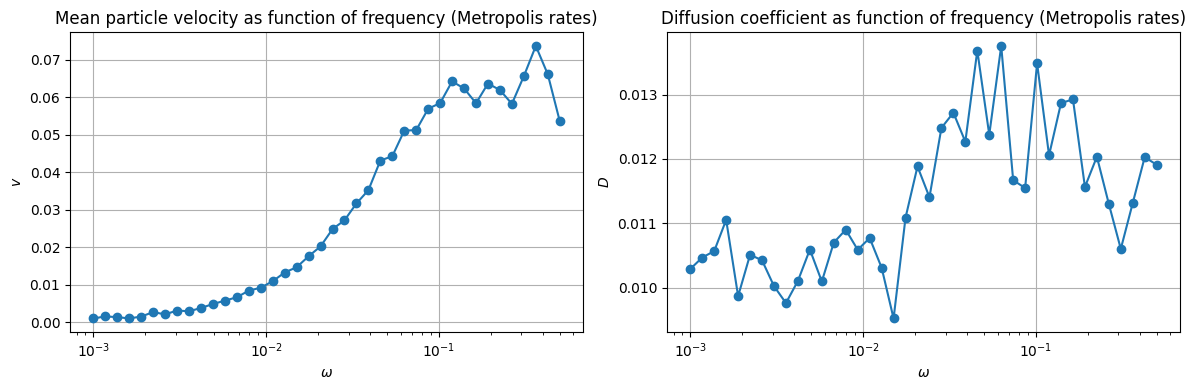

In [124]:
omega_arr = np.logspace(-3, np.log10(0.5), 40)

v_arr, D_arr = compute_velocity_diffusion_omega(
    omega_arr, random_walk_exclusion_sawtooth_m, Np=25, width=1, Nx=6, Ns=50,
    alpha=1/6, k=5.0, beta=2.0, Nc=500
)

plot_velocity_diffusion_omega(omega_arr, v_arr, D_arr, metropolis=True)

Figurene over viser den samme kvalitative trenden som i artikkelen, $v$ stiger med $\omega$ og flater seg noe ut ved høye frekvenser. 

Ved lave $\omega$ vil partiklene ligge i potensialminimumene i ON-tilstanden, og sprer seg deretter symmetrisk i OFF-tilstanden. Netto forflytning per syklus er liten fordi systemet er nær likevekt.

For større $\omega$ vil gjennomsnittlige hastighet øke da forflytningen blir større på kortere tid da potensialet veksler fortere og følgelig vil strømmen av partikler bli større, men for tilstrekkelig store verdier vil det partiklene i liten grad nå likevekt og vil heller ikke diffundere noe særlig på grunn av periodens korthet.

